# 🫁 02 — Training & Testing (3 Classes)
**Models:** EfficientNetB4 (primary) | DenseNet121 | ResNet50

**Run AFTER:** `01_preprocessing.ipynb`

---
### Cell Order
1. Imports
2. Configuration
3. Data Generators
4. Class Weights
5. Model Builders
6. Grad-CAM Function
7. Train EfficientNetB4
8. Train DenseNet121
9. Train ResNet50
10. Evaluate All
11. Final Comparison

## Cell 1 — Imports

In [2]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4, DenseNet121, ResNet50
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, CSVLogger)
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from PIL import Image
import gc

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('✅ All imports successful')

TensorFlow : 2.17.0
GPU        : []
✅ All imports successful


## Cell 2 — Configuration

In [3]:
# ── Update paths if needed ──
DATASET_PATH = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
ORIG_PATH    = r'D:\Files\AI X-Ray Detection\Dataset'
MODELS_PATH  = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH = r'D:\Files\AI X-Ray Detection\Reports'

os.makedirs(MODELS_PATH,  exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# Use augmented dataset if available, else fall back to original
if not os.path.exists(DATASET_PATH):
    print(f'⚠️  Augmented dataset not found — using original')
    DATASET_PATH = ORIG_PATH

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
NUM_CLASSES = 3
EPOCHS      = 25
SEED        = 42
TRAIN_PATH  = os.path.join(DATASET_PATH, 'train')
TEST_PATH   = os.path.join(DATASET_PATH, 'test')

print('✅ Configuration ready')
print(f'   Dataset : {DATASET_PATH}')
print(f'   Models  : {MODELS_PATH}')
print(f'   Results : {RESULTS_PATH}')

✅ Configuration ready
   Dataset : D:\Files\AI X-Ray Detection\Dataset_Cleaned
   Models  : D:\Files\AI X-Ray Detection\Models
   Results : D:\Files\AI X-Ray Detection\Reports


## Cell 3 — Data Generators

In [3]:
# Train — with online augmentation on top of offline augmented data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest',
    validation_split=0.2
)

# Val — rescale ONLY, no augmentation
val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Class mapping : {train_gen.class_indices}')
print(f'Train samples : {train_gen.samples}')
print(f'Val samples   : {val_gen.samples}')
print(f'Test samples  : {test_gen.samples}')
print(f'Classes       : {CLASS_NAMES}')

Found 21600 images belonging to 3 classes.
Found 5400 images belonging to 3 classes.
Found 1451 images belonging to 3 classes.
Class mapping : {'normal': 0, 'pneumonia': 1, 'tuberculosis': 2}
Train samples : 21600
Val samples   : 5400
Test samples  : 1451
Classes       : ['normal', 'pneumonia', 'tuberculosis']


## Cell 4 — Class Weights (Anti-Bias)

In [4]:
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(raw_weights))

# Extra boost for tuberculosis and pneumonia (usually underrepresented)
for idx, cls in enumerate(CLASS_NAMES):
    if 'tubercul' in cls.lower():
        class_weight_dict[idx] *= 1.5
    if 'pneumonia' in cls.lower():
        class_weight_dict[idx] *= 1.3

print('⚖️  Class weights (bias prevention):')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'   [{idx}] {cls:<18} : {class_weight_dict[idx]:.4f}')

⚖️  Class weights (bias prevention):
   [0] normal             : 1.0000
   [1] pneumonia          : 1.3000
   [2] tuberculosis       : 1.5000


## Cell 5 — Model Builders

In [5]:
def build_efficientnet_b4(num_classes):
    """Best accuracy/speed for small medical datasets"""
    base = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    x   = base.output
    x   = GlobalAveragePooling2D()(x)
    x   = BatchNormalization()(x)
    x   = Dense(512, activation='relu')(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out), 'top_activation'

def build_densenet121(num_classes):
    """CheXNet architecture — designed for chest X-rays"""
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base.layers[:-40]:
        layer.trainable = False
    for layer in base.layers[-40:]:
        layer.trainable = True
    x   = base.output
    x   = GlobalAveragePooling2D()(x)
    x   = BatchNormalization()(x)
    x   = Dense(512, activation='relu')(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out), 'relu'

def build_resnet50(num_classes):
    """Baseline comparison"""
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True
    x   = base.output
    x   = GlobalAveragePooling2D()(x)
    x   = BatchNormalization()(x)
    x   = Dense(512, activation='relu')(x)
    x   = Dropout(0.4)(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out), 'conv5_block3_out'

print('✅ Model builders ready')
print('   EfficientNetB4 — primary model')
print('   DenseNet121    — X-ray specialist')
print('   ResNet50       — baseline comparison')

✅ Model builders ready
   EfficientNetB4 — primary model
   DenseNet121    — X-ray specialist
   ResNet50       — baseline comparison


## Cell 6 — Grad-CAM Heatmap Function

In [6]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    try:
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        grads        = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap      = tf.squeeze(heatmap)
        heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
        return heatmap.numpy()
    except Exception as e:
        print(f'Grad-CAM error: {e}')
        return None

def generate_heatmap_grid(model, last_conv, test_path, class_names, save_path, n_per_class=3):
    import random
    n_rows = len(class_names) * n_per_class
    fig, axes = plt.subplots(n_rows, 3, figsize=(14, n_rows * 3.5))
    if n_rows == 1: axes = [axes]
    fig.suptitle('Grad-CAM Heatmaps — Affected Region Detection',
                 fontsize=14, fontweight='bold')
    row = 0
    for cls in class_names:
        cls_dir = os.path.join(test_path, cls)
        if not os.path.isdir(cls_dir): continue
        files   = [f for f in os.listdir(cls_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))]
        samples = random.sample(files, min(n_per_class, len(files)))
        for fname in samples:
            img_path = os.path.join(cls_dir, fname)
            try:
                img      = Image.open(img_path).convert('RGB').resize((224,224))
                img_arr  = np.expand_dims(np.array(img)/255.0, 0).astype(np.float32)
                preds    = model.predict(img_arr, verbose=0)[0]
                pred_idx = int(np.argmax(preds))
                conf     = float(preds[pred_idx])
                pred_cls = class_names[pred_idx]
                heatmap  = make_gradcam_heatmap(img_arr, model, last_conv, pred_idx)
                axes[row][0].imshow(img)
                axes[row][0].set_title(f'Original\nTrue: {cls}', fontsize=8)
                axes[row][0].axis('off')
                if heatmap is not None:
                    hm_r = cv2.resize(heatmap, (224,224))
                    axes[row][1].imshow(hm_r, cmap='jet')
                    hm_c = cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_JET)
                    hm_c = cv2.cvtColor(hm_c, cv2.COLOR_BGR2RGB)
                    overlay = (0.55*np.array(img) + 0.45*hm_c).astype(np.uint8)
                    axes[row][2].imshow(overlay)
                else:
                    axes[row][1].imshow(img)
                    axes[row][2].imshow(img)
                axes[row][1].set_title('Heatmap', fontsize=8); axes[row][1].axis('off')
                color = 'green' if pred_cls == cls else 'red'
                tick  = '✅' if pred_cls == cls else '❌'
                axes[row][2].set_title(f'{tick} {pred_cls}\n{conf*100:.1f}%',
                                       fontsize=8, color=color, fontweight='bold')
                axes[row][2].axis('off')
            except Exception as e:
                for j in range(3): axes[row][j].axis('off')
            row += 1
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Heatmap grid saved → {save_path}')

print('✅ Grad-CAM functions ready')

✅ Grad-CAM functions ready


## Cell 7 — Training Function

In [7]:
all_results = []  # stores results from all trained models

def train_model(model_name, build_fn):
    print(f'\n{"="*55}')
    print(f'  TRAINING: {model_name}')
    print(f'{"="*55}')

    model, last_conv = build_fn(NUM_CLASSES)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Trainable layers: {trainable}/{len(model.layers)}')

    save_path = os.path.join(MODELS_PATH, f'{model_name}_best.keras')
    log_path  = os.path.join(RESULTS_PATH, f'{model_name}_log.csv')

    callbacks = [
        ModelCheckpoint(save_path, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=6,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
        CSVLogger(log_path)
    ]

    print(f'\n  🚀 Training...')
    history = model.fit(
        train_gen, epochs=EPOCHS,
        validation_data=val_gen,
        class_weight=class_weight_dict,
        callbacks=callbacks, verbose=1
    )

    best_val = max(history.history['val_accuracy'])
    print(f'\n  ✅ Best Val Accuracy: {best_val*100:.2f}%')

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],          label='Train', color='#4f86f7', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   color='#a855f7', linewidth=2)
        ax.set_title(metric.capitalize())
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{model_name}_curves.png'), dpi=150)
    plt.show()

    return model, last_conv, history, save_path, best_val

print('✅ Training function ready')

✅ Training function ready


## Cell 8 — Evaluation Function

In [8]:
def evaluate_model(model, model_name, last_conv, best_val):
    print(f'\n  Evaluating {model_name} on test set...')
    test_gen.reset()
    y_pred         = model.predict(test_gen, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true         = test_gen.classes
    overall_acc    = float(np.sum(y_pred_classes == y_true) / len(y_true))

    report_str  = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES)
    report_dict = classification_report(y_true, y_pred_classes,
                                        target_names=CLASS_NAMES, output_dict=True)
    print(f'\n  {"-"*50}')
    print(f'  {model_name} — Test Results')
    print(f'  {"-"*50}')
    print(report_str)

    # Save report
    with open(os.path.join(RESULTS_PATH, f'{model_name}_report.txt'), 'w') as f:
        f.write(f'Model: {model_name}\n\n{report_str}')

    # Confusion Matrix
    cm  = confusion_matrix(y_true, y_pred_classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    im  = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im)
    ax.set(xticks=np.arange(len(CLASS_NAMES)), yticks=np.arange(len(CLASS_NAMES)),
           xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
           ylabel='True Label', xlabel='Predicted Label',
           title=f'Confusion Matrix — {model_name}')
    plt.setp(ax.get_xticklabels(), rotation=15)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i,j],'d'), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > thresh else 'black')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{model_name}_confusion.png'), dpi=150)
    plt.show()

    # ROC Curves
    y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
    auc_scores = {}
    fig, ax    = plt.subplots(figsize=(9, 7))
    colors_roc = ['#4f86f7', '#ef4444', '#a855f7']
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
        try:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
            auc         = float(roc_auc_score(y_true_bin[:, i], y_pred[:, i]))
            auc_scores[cls] = auc
            ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC={auc:.3f})')
        except Exception as e:
            print(f'  ROC error {cls}: {e}')
    ax.plot([0,1],[0,1],'k--')
    ax.set(xlabel='FPR', ylabel='TPR', title=f'ROC Curves — {model_name}')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{model_name}_roc.png'), dpi=150)
    plt.show()

    # Per-class recall bias check
    print(f'\n  Per-class Recall (Bias Check):')
    recalls = {}
    for i, cls in enumerate(CLASS_NAMES):
        mask   = y_true == i
        rec    = float(np.sum((y_pred_classes == i) & mask) / (mask.sum() + 1e-9))
        recalls[cls] = rec
        flag   = '✅' if rec >= 0.80 else '⚠️  LOW'
        print(f'    {cls:<18} recall = {rec:.3f}  {flag}')

    # Grad-CAM Heatmaps
    heatmap_path = os.path.join(RESULTS_PATH, f'{model_name}_heatmaps.png')
    generate_heatmap_grid(model, last_conv, TEST_PATH, CLASS_NAMES, heatmap_path)

    result = {
        'model_name'      : model_name,
        'best_val_accuracy': round(float(best_val), 4),
        'test_accuracy'   : round(overall_acc, 4),
        'recalls'         : {k: round(v,4) for k,v in recalls.items()},
        'auc_scores'      : {k: round(v,4) for k,v in auc_scores.items()},
    }
    all_results.append(result)
    return result

print('✅ Evaluation function ready')

✅ Evaluation function ready


## Cell 9 — Train EfficientNetB4 (Primary Model)

In [ ]:
model_eff, conv_eff, hist_eff, path_eff, val_eff = train_model(
    'EfficientNetB4', build_efficientnet_b4
)
result_eff = evaluate_model(model_eff, 'EfficientNetB4', conv_eff, val_eff)
del model_eff; gc.collect()
print('\n✅ EfficientNetB4 complete')


  TRAINING: EfficientNetB4
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 52s 1us/step
  Trainable layers: 37/482

  🚀 Training...
Epoch 1/25
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.3418 - loss: 1.8924
Epoch 1: val_accuracy improved from None to 0.38833, saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras

Epoch 1: finished saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 1212s 885ms/step - accuracy: 0.3416 - loss: 1.7345 - val_accuracy: 0.3883 - val_loss: 1.0986 - learning_rate: 1.0000e-04
Epoch 2/25
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.3486 - loss: 1.4892
Epoch 2: val_accuracy improved from 0.38833 to 0.41056, saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras

Epoch 2: finished saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 1164s 862ms/step - accuracy: 0.3457 - loss: 1.4722 - val_a

## Cell 10 — Train DenseNet121

In [ ]:
model_dn, conv_dn, hist_dn, path_dn, val_dn = train_model(
    'DenseNet121', build_densenet121
)
result_dn = evaluate_model(model_dn, 'DenseNet121', conv_dn, val_dn)
del model_dn; gc.collect()
print('\n✅ DenseNet121 complete')

## Cell 11 — Train ResNet50 (Baseline)

In [ ]:
model_rn, conv_rn, hist_rn, path_rn, val_rn = train_model(
    'ResNet50', build_resnet50
)
result_rn = evaluate_model(model_rn, 'ResNet50', conv_rn, val_rn)
del model_rn; gc.collect()
print('\n✅ ResNet50 complete')

## Cell 12 — Final Comparison Table

In [ ]:
print(f'\n{"="*65}')
print('  FINAL MODEL COMPARISON')
print(f'{"="*65}')
print(f'  {"Model":<20} {"Val Acc":>10} {"Test Acc":>10}', end='')
for cls in CLASS_NAMES:
    print(f'  {cls[:6]+" R":>10}', end='')
print()
print(f'  {"-"*63}')

best_name = None
best_acc  = 0
for r in all_results:
    recalls = [r['recalls'].get(cls, 0) for cls in CLASS_NAMES]
    flag    = '🏆' if r == max(all_results, key=lambda x: x['test_accuracy']) else '  '
    print(f'  {flag} {r["model_name"]:<18} {r["best_val_accuracy"]:>10.4f} '
          f'{r["test_accuracy"]:>10.4f}' + ''.join(f'  {rec:>10.4f}' for rec in recalls))
    if r['test_accuracy'] > best_acc:
        best_acc  = r['test_accuracy']
        best_name = r['model_name']

best_result = next(r for r in all_results if r['model_name'] == best_name)

# Save comparison
pd.DataFrame(all_results).to_csv(
    os.path.join(RESULTS_PATH, 'model_comparison.csv'), index=False)

# Save best model info for other scripts
best_info = {
    'best_model'    : best_name,
    'model_path'    : os.path.join(MODELS_PATH, f'{best_name}_best.keras'),
    'test_accuracy' : best_result['test_accuracy'],
    'class_names'   : CLASS_NAMES,
    'num_classes'   : NUM_CLASSES
}
with open(os.path.join(RESULTS_PATH, 'best_model_info.json'), 'w') as f:
    json.dump(best_info, f, indent=2)

print(f'\n  🏆 Best Model : {best_name}')
print(f'     Test Acc   : {best_acc*100:.2f}%')
print(f'\n  Update ml_api.py:')
print(f'     MODEL_PATH  = r\'{ os.path.join(MODELS_PATH, best_name+"_best.keras") }\'')
print(f'     CLASS_NAMES = {CLASS_NAMES}')
print(f'\n  ✅ All results saved to: {RESULTS_PATH}')

After 10 Epochs 

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Paths
DATASET_PATH = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
MODELS_PATH  = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH = r'D:\Files\AI X-Ray Detection\Reports'
TRAIN_PATH   = os.path.join(DATASET_PATH, 'train')
TEST_PATH    = os.path.join(DATASET_PATH, 'test')
SAVE_PATH    = os.path.join(MODELS_PATH, 'EfficientNetB4_best.keras')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
SEED       = 42

# Load saved model
print('Loading saved model...')
model = tf.keras.models.load_model(SAVE_PATH, compile=False)
print(f'✅ Model loaded — resuming from Epoch 15')

# Recompile
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Recreate generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest',
    validation_split=0.2
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=SEED
)

CLASS_NAMES = list(train_gen.class_indices.keys())

# Class weights
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(raw_weights))
for idx, cls in enumerate(CLASS_NAMES):
    if 'tubercul' in cls.lower():
        class_weight_dict[idx] *= 1.5
    if 'pneumonia' in cls.lower():
        class_weight_dict[idx] *= 1.3

# Callbacks
callbacks = [
    ModelCheckpoint(SAVE_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    CSVLogger(os.path.join(RESULTS_PATH, 'EfficientNetB4_resumed_log.csv'),
              append=True)   # ← add append=True
]

# Resume training for remaining epochs
print('\nResuming training from Epoch 15...')
history = model.fit(
    train_gen,
    epochs=25,           # remaining epochs
    initial_epoch=15,    # ← tells Keras we already did 10 epochs
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_val = max(history.history['val_accuracy'])
print(f'\n✅ Resumed training complete!')
print(f'   Best Val Accuracy: {best_val*100:.2f}%')

Loading saved model...
✅ Model loaded — resuming from Epoch 15
Found 21600 images belonging to 3 classes.
Found 5400 images belonging to 3 classes.

Resuming training from Epoch 15...
Epoch 16/25
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.5944 - loss: 1.0127
Epoch 16: val_accuracy improved from None to 0.72241, saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras

Epoch 16: finished saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 1279s 935ms/step - accuracy: 0.6019 - loss: 1.0075 - val_accuracy: 0.7224 - val_loss: 0.6316 - learning_rate: 1.0000e-04
Epoch 17/25
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.6056 - loss: 1.0076
Epoch 17: val_accuracy improved from 0.72241 to 0.73019, saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras

Epoch 17: finished saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_best.keras
1350/1350 ━━━━━━━━━━━━━

Loading model for fine-tuning...
✅ Model loaded
   Current trainable layers: 38
   Fine-tuning trainable layers: 80
   Learning rate: 0.00001 (10x lower for fine-tuning)
Found 21600 images belonging to 3 classes.
Found 5400 images belonging to 3 classes.

   Classes : ['normal', 'pneumonia', 'tuberculosis']
   Train   : 21600
   Val     : 5400

⚖️  Class weights:
   [0] normal             : 1.0000
   [1] pneumonia          : 1.3000
   [2] tuberculosis       : 1.5000

  FINE-TUNING PHASE
  Starting from val_accuracy = 75.22%
  Target: 83-88%

🚀 Fine-tuning started...

Epoch 26/35
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.6540 - loss: 0.9053
Epoch 26: val_accuracy improved from None to 0.73111, saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_finetuned.keras

Epoch 26: finished saving model to D:\Files\AI X-Ray Detection\Models\EfficientNetB4_finetuned.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 1241s 906ms/step - accuracy: 0.6570 - loss: 0.9043 - val_accuracy:

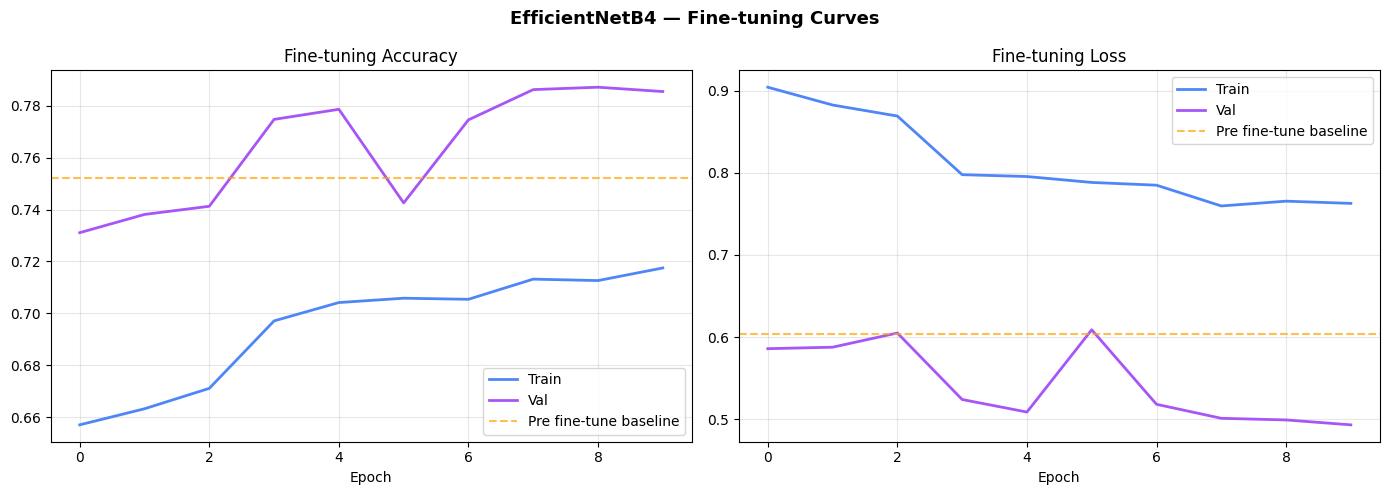

📊 Fine-tuning curves saved

  Update ml_api.py with:
  MODEL_PATH  = r'D:\Files\AI X-Ray Detection\Models\EfficientNetB4_finetuned.keras'
  CLASS_NAMES = ['normal', 'pneumonia', 'tuberculosis']


In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──
DATASET_PATH  = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
MODELS_PATH   = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH  = r'D:\Files\AI X-Ray Detection\Reports'
TRAIN_PATH    = os.path.join(DATASET_PATH, 'train')
SAVE_PATH     = os.path.join(MODELS_PATH, 'EfficientNetB4_best.keras')
FINETUNE_PATH = os.path.join(MODELS_PATH, 'EfficientNetB4_finetuned.keras')
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16
SEED          = 42

# ── Step 1: Load saved model ──
print('Loading model for fine-tuning...')
model = tf.keras.models.load_model(SAVE_PATH, compile=False)
print(f'✅ Model loaded')
print(f'   Current trainable layers: {sum(1 for l in model.layers if l.trainable)}')

# ── Step 2: Unfreeze last 100 layers ──
# First freeze everything
for layer in model.layers:
    layer.trainable = False

# Then unfreeze last 100
for layer in model.layers[-100:]:
    layer.trainable = True

# Always keep BatchNorm frozen — important for fine-tuning stability
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_now = sum(1 for l in model.layers if l.trainable)
print(f'   Fine-tuning trainable layers: {trainable_now}')

# ── Step 3: Recompile with lower learning rate ──
model.compile(
    optimizer=Adam(learning_rate=0.00001),  # 10x lower than before
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(f'   Learning rate: 0.00001 (10x lower for fine-tuning)')

# ── Step 4: Recreate generators ──
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,           # less augmentation for fine-tuning
    width_shift_range=0.06,
    height_shift_range=0.06,
    horizontal_flip=True,
    zoom_range=0.08,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=0.2
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training',
    shuffle=True, seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation',
    shuffle=False, seed=SEED
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'\n   Classes : {CLASS_NAMES}')
print(f'   Train   : {train_gen.samples}')
print(f'   Val     : {val_gen.samples}')

# ── Step 5: Class weights ──
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(raw_weights))
for idx, cls in enumerate(CLASS_NAMES):
    if 'tubercul' in cls.lower():
        class_weight_dict[idx] *= 1.5
    if 'pneumonia' in cls.lower():
        class_weight_dict[idx] *= 1.3

print('\n⚖️  Class weights:')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'   [{idx}] {cls:<18} : {class_weight_dict[idx]:.4f}')

# ── Step 6: Callbacks ──
callbacks = [
    ModelCheckpoint(
        FINETUNE_PATH,           # saves to new file — keeps original safe
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,              # slightly less patience for fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,              # more aggressive reduction
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    CSVLogger(
        os.path.join(RESULTS_PATH, 'EfficientNetB4_finetuning_log.csv'),
        append=False
    )
]

# ── Step 7: Fine-tune ──
print(f'\n{"="*55}')
print(f'  FINE-TUNING PHASE')
print(f'  Starting from val_accuracy = 75.22%')
print(f'  Target: 83-88%')
print(f'{"="*55}')
print(f'\n🚀 Fine-tuning started...\n')

history_ft = model.fit(
    train_gen,
    epochs=35,              # ceiling — early stopping will trigger before this
    initial_epoch=25,       # continues from where training left off
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

best_val = max(history_ft.history['val_accuracy'])
print(f'\n{"="*55}')
print(f'  ✅ FINE-TUNING COMPLETE')
print(f'  Best Val Accuracy : {best_val*100:.2f}%')
print(f'  Improvement       : {(best_val - 0.7522)*100:+.2f}% from 75.22%')
print(f'  Model saved to    : {FINETUNE_PATH}')
print(f'{"="*55}')

# ── Step 8: Plot fine-tuning curves ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB4 — Fine-tuning Curves', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_ft.history[metric],
            label='Train', color='#4f86f7', linewidth=2)
    ax.plot(history_ft.history[f'val_{metric}'],
            label='Val', color='#a855f7', linewidth=2)
    ax.axhline(y=0.7522 if metric == 'accuracy' else 0.6035,
               color='orange', linestyle='--', alpha=0.7,
               label='Pre fine-tune baseline')
    ax.set_title(f'Fine-tuning {metric.capitalize()}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'EfficientNetB4_finetuning_curves.png'), dpi=150)
plt.show()
print(f'📊 Fine-tuning curves saved')

# ── Step 9: Update best model info ──
import json
best_info = {
    'best_model'    : 'EfficientNetB4_finetuned',
    'model_path'    : FINETUNE_PATH,
    'test_accuracy' : round(float(best_val), 4),
    'class_names'   : CLASS_NAMES,
    'num_classes'   : len(CLASS_NAMES),
    'phase'         : 'fine-tuned',
    'base_accuracy' : 0.7522
}
with open(os.path.join(RESULTS_PATH, 'best_model_info.json'), 'w') as f:
    json.dump(best_info, f, indent=2)

print(f'\n  Update ml_api.py with:')
print(f'  MODEL_PATH  = r\'{FINETUNE_PATH}\'')
print(f'  CLASS_NAMES = {CLASS_NAMES}')


Loading fine-tuned model...
✅ Model loaded
Found 1451 images belonging to 3 classes.
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 531ms/step

  TEST SET RESULTS — Fine-tuned EfficientNetB4
              precision    recall  f1-score   support

      normal       0.82      0.85      0.84       476
   pneumonia       0.91      0.97      0.94       432
tuberculosis       0.90      0.82      0.85       543

    accuracy                           0.87      1451
   macro avg       0.88      0.88      0.88      1451
weighted avg       0.88      0.87      0.87      1451

  Per-class Recall (Bias Check):
    normal             recall = 0.853  ✅
    pneumonia          recall = 0.972  ✅
    tuberculosis       recall = 0.816  ✅


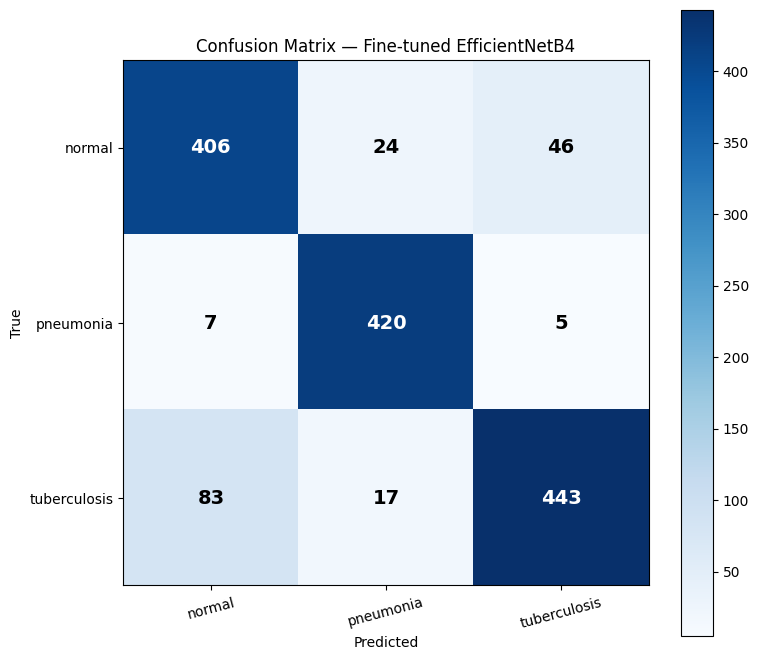


  Overall Test Accuracy : 87.46%
  Results saved → D:\Files\AI X-Ray Detection\Reports


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve

DATASET_PATH  = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
MODELS_PATH   = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH  = r'D:\Files\AI X-Ray Detection\Reports'
FINETUNE_PATH = os.path.join(MODELS_PATH, 'EfficientNetB4_finetuned.keras')
TEST_PATH     = os.path.join(DATASET_PATH, 'test')
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16

# Load model
print('Loading fine-tuned model...')
model = tf.keras.models.load_model(FINETUNE_PATH, compile=False)
print('✅ Model loaded')

# Test generator
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
CLASS_NAMES = list(test_gen.class_indices.keys())

# Predict
test_gen.reset()
y_pred         = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = test_gen.classes
overall_acc    = float(np.sum(y_pred_classes == y_true) / len(y_true))

# Report
print(f'\n{"="*55}')
print(f'  TEST SET RESULTS — Fine-tuned EfficientNetB4')
print(f'{"="*55}')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

# Per-class recall
print(f'  Per-class Recall (Bias Check):')
for i, cls in enumerate(CLASS_NAMES):
    mask   = y_true == i
    rec    = float(np.sum((y_pred_classes == i) & mask) / mask.sum())
    flag   = '✅' if rec >= 0.80 else '⚠️  LOW'
    print(f'    {cls:<18} recall = {rec:.3f}  {flag}')

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar(im)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > thresh else 'black')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Fine-tuned EfficientNetB4')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'finetuned_confusion_matrix.png'), dpi=150)
plt.show()

print(f'\n  Overall Test Accuracy : {overall_acc*100:.2f}%')
print(f'  Results saved → {RESULTS_PATH}')